# IRIS — YOLOv11s Screw Detection Training
> **Intelligent Robotic Identification and Sorting**  
> Model: `yolo11s.pt` | Epochs: 2000 | Early stop patience: 100

### Before running:
1. `Runtime → Change runtime type → T4 GPU` (free) or A100 (Colab Pro)
2. Fill in `CONFIG` cell below with your Roboflow API key and dataset info
3. Run all cells top to bottom

---
### Where to get the dataset
1. Go to [universe.roboflow.com](https://universe.roboflow.com)
2. Search **"screw detection"** — filter by Most Images, select a dataset with ≥1k images
3. Click **Download** → Format: `YOLOv11` → Show download code → copy the snippet
4. Paste your `api_key`, `workspace`, `project`, and `version` into the CONFIG cell

In [2]:
# ============================================================
# CONFIG — edit these before running
# ============================================================
ROBOFLOW_API_KEY  = "vbActUQwASGoKvkJ2tPD"   # from app.roboflow.com → settings → API
ROBOFLOW_WORKSPACE = "jonahchang207"      # e.g. "jonah-chang"
ROBOFLOW_PROJECT   = "screws-b1tqq-vrwzs"        # e.g. "screw-detection"
ROBOFLOW_VERSION   = 1                     # dataset version number

MODEL_SIZE   = "yolo11s.pt"   # yolo11n (fastest) | yolo11s (recommended) | yolo11m
EPOCHS       = 10
PATIENCE     = 100            # early stop if no improvement for N epochs
IMGSZ        = 640
BATCH        = 16             # reduce to 8 if OOM on free T4
PROJECT_NAME = "IRIS_screw_detection"
RUN_NAME     = "yolo11s_2000ep"
DEVICE       = 0              # GPU index; 'cpu' to force CPU

## 1. Environment Setup

In [3]:
# Verify GPU
import subprocess
result = subprocess.run(['nvidia-smi'], capture_output=True, text=True)
print(result.stdout if result.returncode == 0 else 'No GPU detected — check runtime type')

Wed Mar 18 03:01:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             72W /   70W |    4781MiB /  15360MiB |     73%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
# Install dependencies
!pip install -q ultralytics roboflow inference-sdk
import ultralytics
ultralytics.checks()

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 44.9/112.6 GB disk)


## 2. Dataset Download

In [5]:
from roboflow import Roboflow
import os

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(ROBOFLOW_WORKSPACE).project(ROBOFLOW_PROJECT)
version = project.version(ROBOFLOW_VERSION)
dataset = version.download("yolov11", location="/content/dataset")

DATASET_YAML = dataset.location + "/data.yaml"
print(f"Dataset location : {dataset.location}")
print(f"YAML             : {DATASET_YAML}")

loading Roboflow workspace...
loading Roboflow project...
Dataset location : /content/dataset
YAML             : /content/dataset/data.yaml


In [6]:
# Inspect dataset
import yaml
from pathlib import Path

with open(DATASET_YAML) as f:
    data = yaml.safe_load(f)

print("Classes  :", data.get('names'))
print("nc       :", data.get('nc'))

train_path = Path(dataset.location) / 'train' / 'images'
val_path   = Path(dataset.location) / 'valid' / 'images'
test_path  = Path(dataset.location) / 'test'  / 'images'

def count(p): return len(list(p.glob('*'))) if p.exists() else 0
print(f"Train: {count(train_path)} | Val: {count(val_path)} | Test: {count(test_path)}")

total = count(train_path) + count(val_path) + count(test_path)
if total < 1000:
    print(f"\n⚠  Only {total} images total — consider a larger dataset for best results")
else:
    print(f"\n✓  {total} total images — good to go")

Classes  : ['Allen', 'Cross', 'Slotted', 'Torx', 'Triangle']
nc       : 5
Train: 6334 | Val: 894 | Test: 1814

✓  9042 total images — good to go


## 3. Training

In [ ]:
from ultralytics import YOLO

model = YOLO(MODEL_SIZE)

results = model.train(
    data      = DATASET_YAML,
    epochs    = 2,
    patience  = PATIENCE,
    imgsz     = IMGSZ,
    batch     = BATCH,
    device    = DEVICE,
    project   = PROJECT_NAME,
    name      = RUN_NAME,
    # Augmentation — tuned for small industrial objects
    hsv_h     = 0.015,   # hue shift (minimal — screws don't change hue)
    hsv_s     = 0.5,     # saturation
    hsv_v     = 0.4,     # brightness
    degrees   = 15.0,    # rotation — screws appear at any angle
    translate = 0.1,
    scale     = 0.5,
    shear     = 2.0,
    flipud    = 0.5,     # screws look same upside-down
    fliplr    = 0.5,
    mosaic    = 1.0,
    mixup     = 0.1,
    copy_paste= 0.1,     # paste extra screw instances into scenes
    # Optimizer
    optimizer = 'AdamW',
    lr0       = 0.001,
    lrf       = 0.01,
    warmup_epochs = 5,
    # Regularization
    weight_decay = 0.0005,
    dropout   = 0.0,
    # Logging
    plots     = True,
    save      = True,
    save_period = 50,    # checkpoint every 50 epochs
    verbose   = True,
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=15.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo11s_2000ep6, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, persp

## 4. Validation

In [ ]:
from pathlib import Path

best_weights = Path(results.save_dir) / "weights" / "best.pt"
model_best = YOLO(str(best_weights))

metrics = model_best.val(
    data   = DATASET_YAML,
    imgsz  = IMGSZ,
    device = DEVICE,
    split  = 'test',
)

print(f"mAP@0.5      : {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95 : {metrics.box.map:.4f}")
print(f"Precision    : {metrics.box.mp:.4f}")
print(f"Recall       : {metrics.box.mr:.4f}")

if metrics.box.map50 < 0.85:
    print("\n⚠  mAP@0.5 below 0.85 target — consider more data or longer training")
else:
    print("\n✓  mAP@0.5 target met")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 101 layers, 9,414,735 parameters, 0 gradients, 21.3 GFLOPs
val: Fast image access ✅ (ping: 0.1±0.0 ms, read: 25.8±14.9 MB/s, size: 91.0 KB)
val: Scanning /content/dataset/test/labels... 1814 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1814/1814 291.6it/s 6.2s0.1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 114/114 1.9it/s 1:010.4ss
                   all       1814       9637       0.91       0.91      0.921      0.578
                 Allen        379       2043          1      0.966      0.995      0.689
                 Cross        321       1926      0.614      0.643      0.643      0.204
               Slotted        371       2102      0.976      0.988      0.991      0.678
                  Torx        371       1821      0.996      0.996     

## 5. Training Visualizations

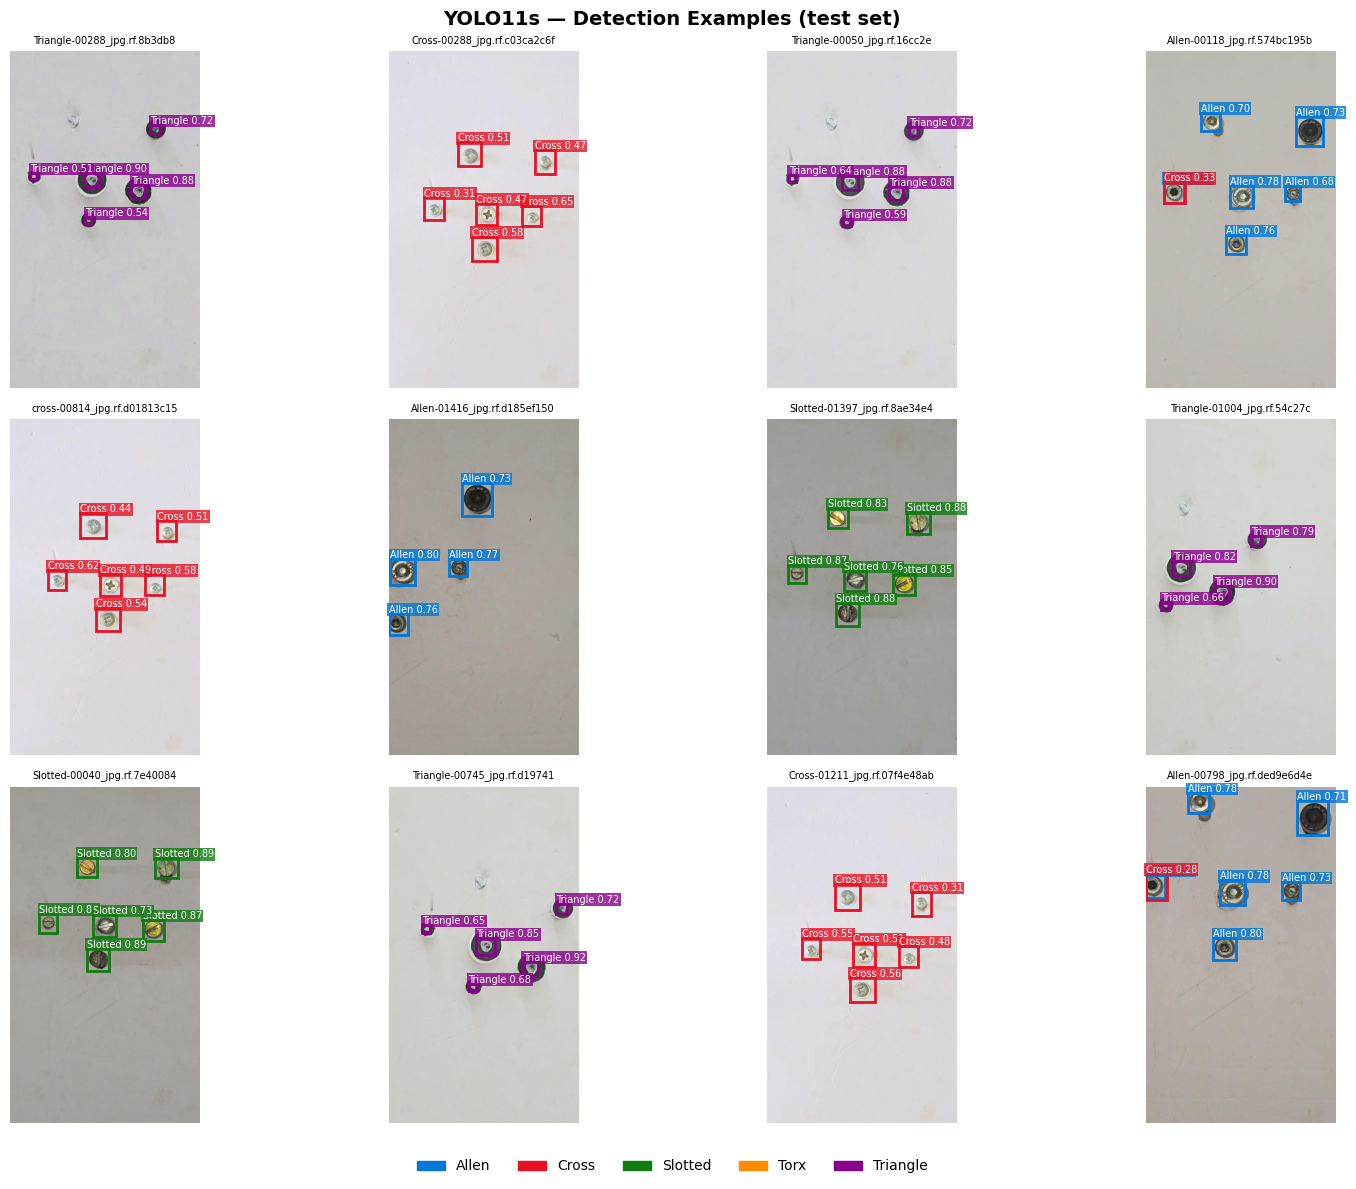

Saved → /content/detection_examples.png


In [ ]:

# ── Detection examples: 12-image grid from test set ───────────────────────────
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

CONF_THRESH = 0.25
IOU_THRESH  = 0.45
N_COLS, N_ROWS = 4, 3

# Class colours — one per screw type
PALETTE = {
    0: (0,   120, 215),   # Allen   — blue
    1: (232,  17,  35),   # Cross   — red
    2: ( 16, 124, 16),    # Slotted — green
    3: (255, 140,   0),   # Torx    — orange
    4: (136,   0, 138),   # Triangle— purple
}

test_images = list((Path(dataset.location) / 'test' / 'images').glob('*'))
sample_paths = random.sample(test_images, min(N_COLS * N_ROWS, len(test_images)))

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(16, 12))
fig.suptitle("YOLO11s — Detection Examples (test set)", fontsize=14, fontweight='bold')
axes = axes.flatten()

for ax, img_path in zip(axes, sample_paths):
    preds = model_best(str(img_path), conf=CONF_THRESH, iou=IOU_THRESH, verbose=False)
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w = img_rgb.shape[:2]

    for box in preds[0].boxes:
        cls_id  = int(box.cls)
        conf    = float(box.conf)
        x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())
        colour  = tuple(c / 255 for c in PALETTE.get(cls_id, (200, 200, 200)))
        label   = f"{metrics.names[cls_id]} {conf:.2f}"

        rect = mpatches.FancyBboxPatch(
            (x1, y1), x2 - x1, y2 - y1,
            boxstyle="square,pad=0", linewidth=2,
            edgecolor=colour, facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(x1, max(y1 - 4, 0), label, fontsize=7, color='white',
                bbox=dict(facecolor=colour, alpha=0.8, pad=1, edgecolor='none'))

    ax.imshow(img_rgb)
    ax.set_title(img_path.name[:28], fontsize=7)
    ax.axis('off')

# Hide any unused axes
for ax in axes[len(sample_paths):]:
    ax.axis('off')

# Legend
legend_patches = [
    mpatches.Patch(color=tuple(c/255 for c in col), label=metrics.names[i])
    for i, col in PALETTE.items() if i in metrics.names
]
fig.legend(handles=legend_patches, loc='lower center', ncol=len(legend_patches),
           fontsize=10, frameon=False, bbox_to_anchor=(0.5, 0))

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig("/content/detection_examples.png", dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → /content/detection_examples.png")


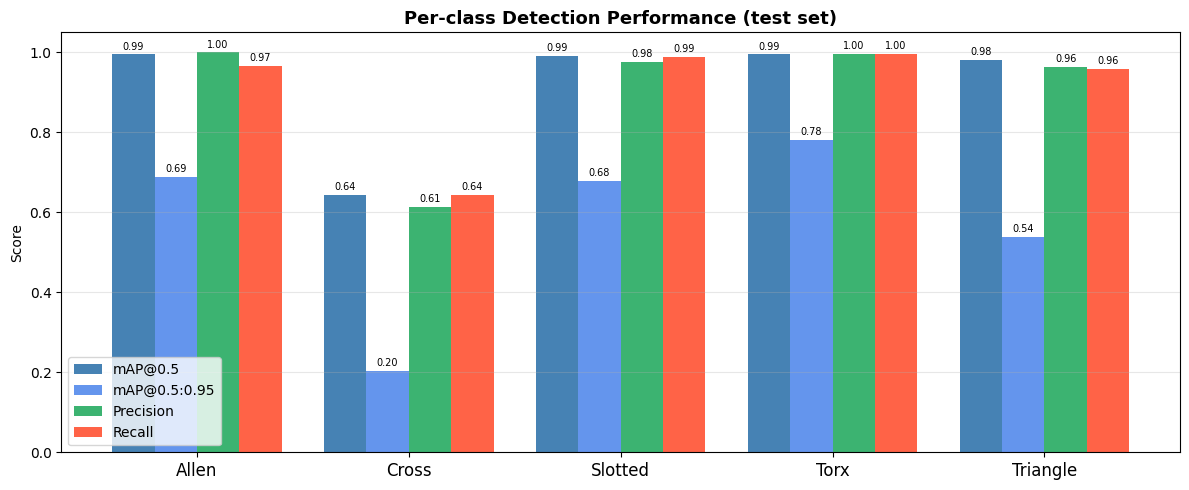

Saved → /content/per_class_stats.png


In [ ]:

# ── Per-class stats bar chart (from test-set validation) ─────────────────────
import matplotlib.pyplot as plt
import numpy as np

class_names = metrics.names  # dict {0: 'Allen', ...}
labels = [class_names[i] for i in sorted(class_names)]

map50_vals    = metrics.box.ap50.tolist()
map5095_vals  = metrics.box.ap.tolist()
prec_vals     = metrics.box.p.tolist()
rec_vals      = metrics.box.r.tolist()

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x - 1.5*width, map50_vals,   width, label='mAP@0.5',       color='steelblue')
ax.bar(x - 0.5*width, map5095_vals, width, label='mAP@0.5:0.95',  color='cornflowerblue')
ax.bar(x + 0.5*width, prec_vals,    width, label='Precision',      color='mediumseagreen')
ax.bar(x + 1.5*width, rec_vals,     width, label='Recall',         color='tomato')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Score")
ax.set_title("Per-class Detection Performance (test set)", fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bars in ax.containers:
    ax.bar_label(bars, fmt='%.2f', fontsize=7, padding=2)

plt.tight_layout()
plt.savefig("/content/per_class_stats.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/per_class_stats.png")


── confusion_matrix_normalized.png ──


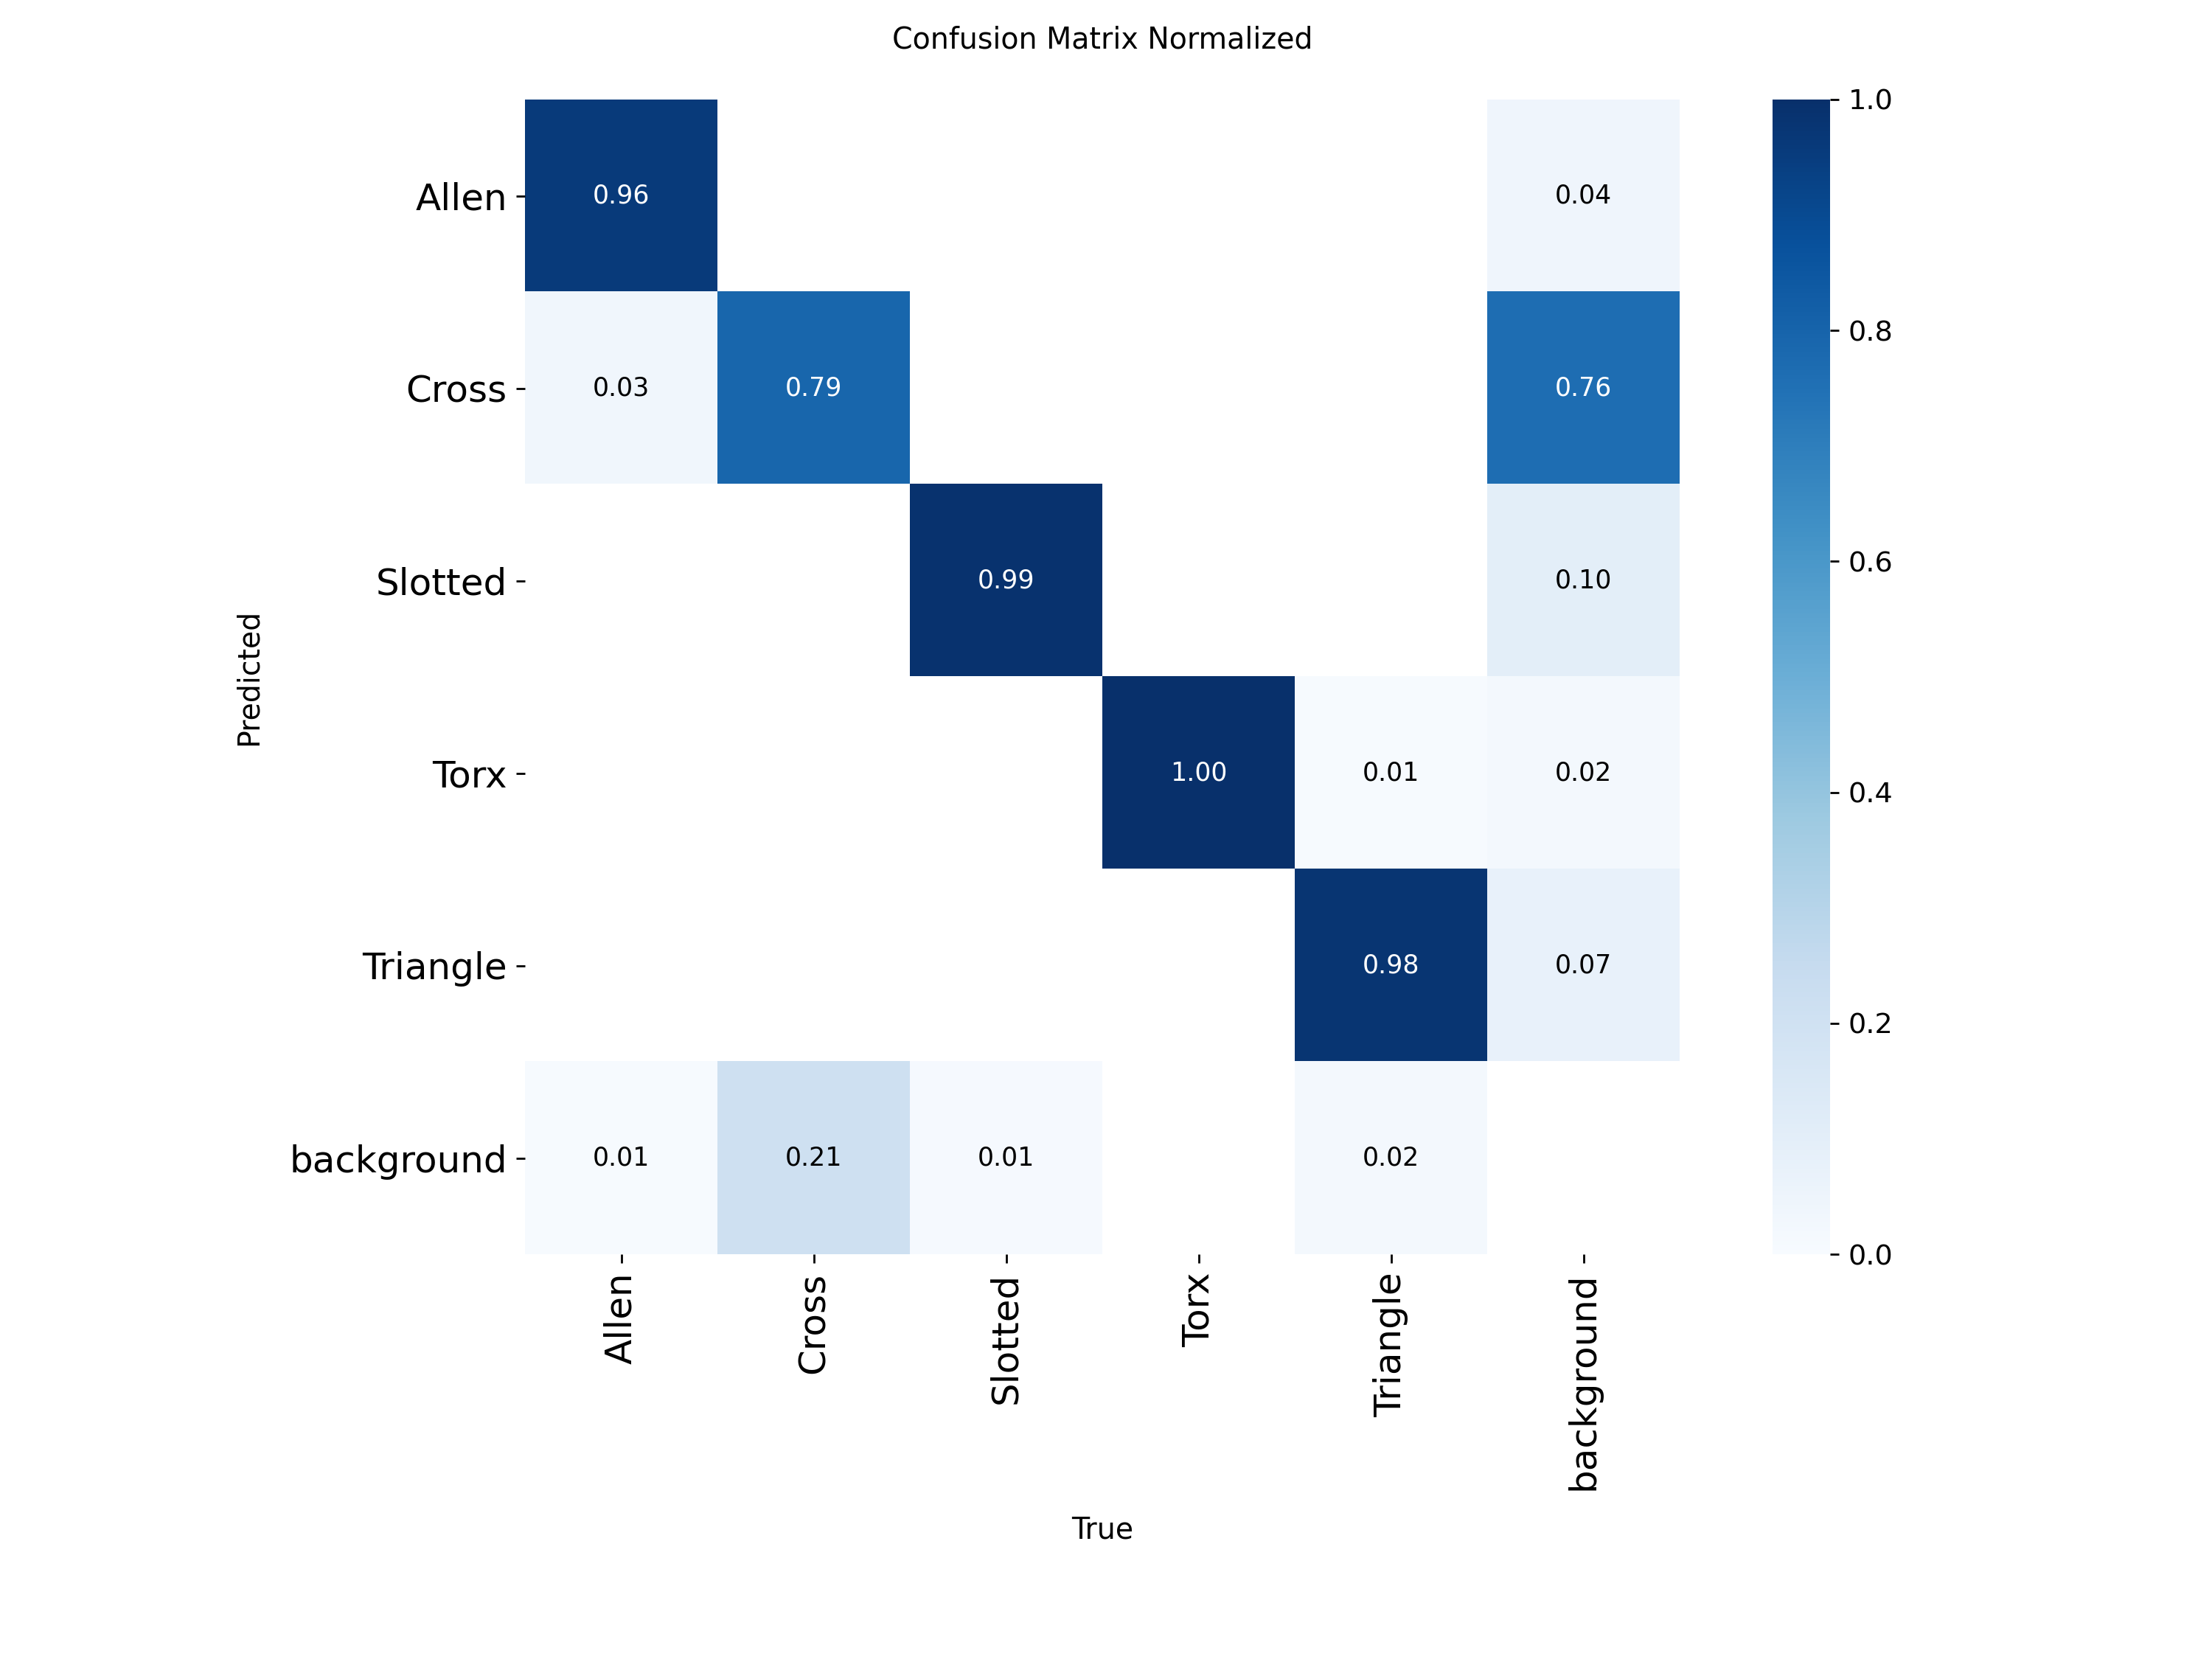

── confusion_matrix.png ──


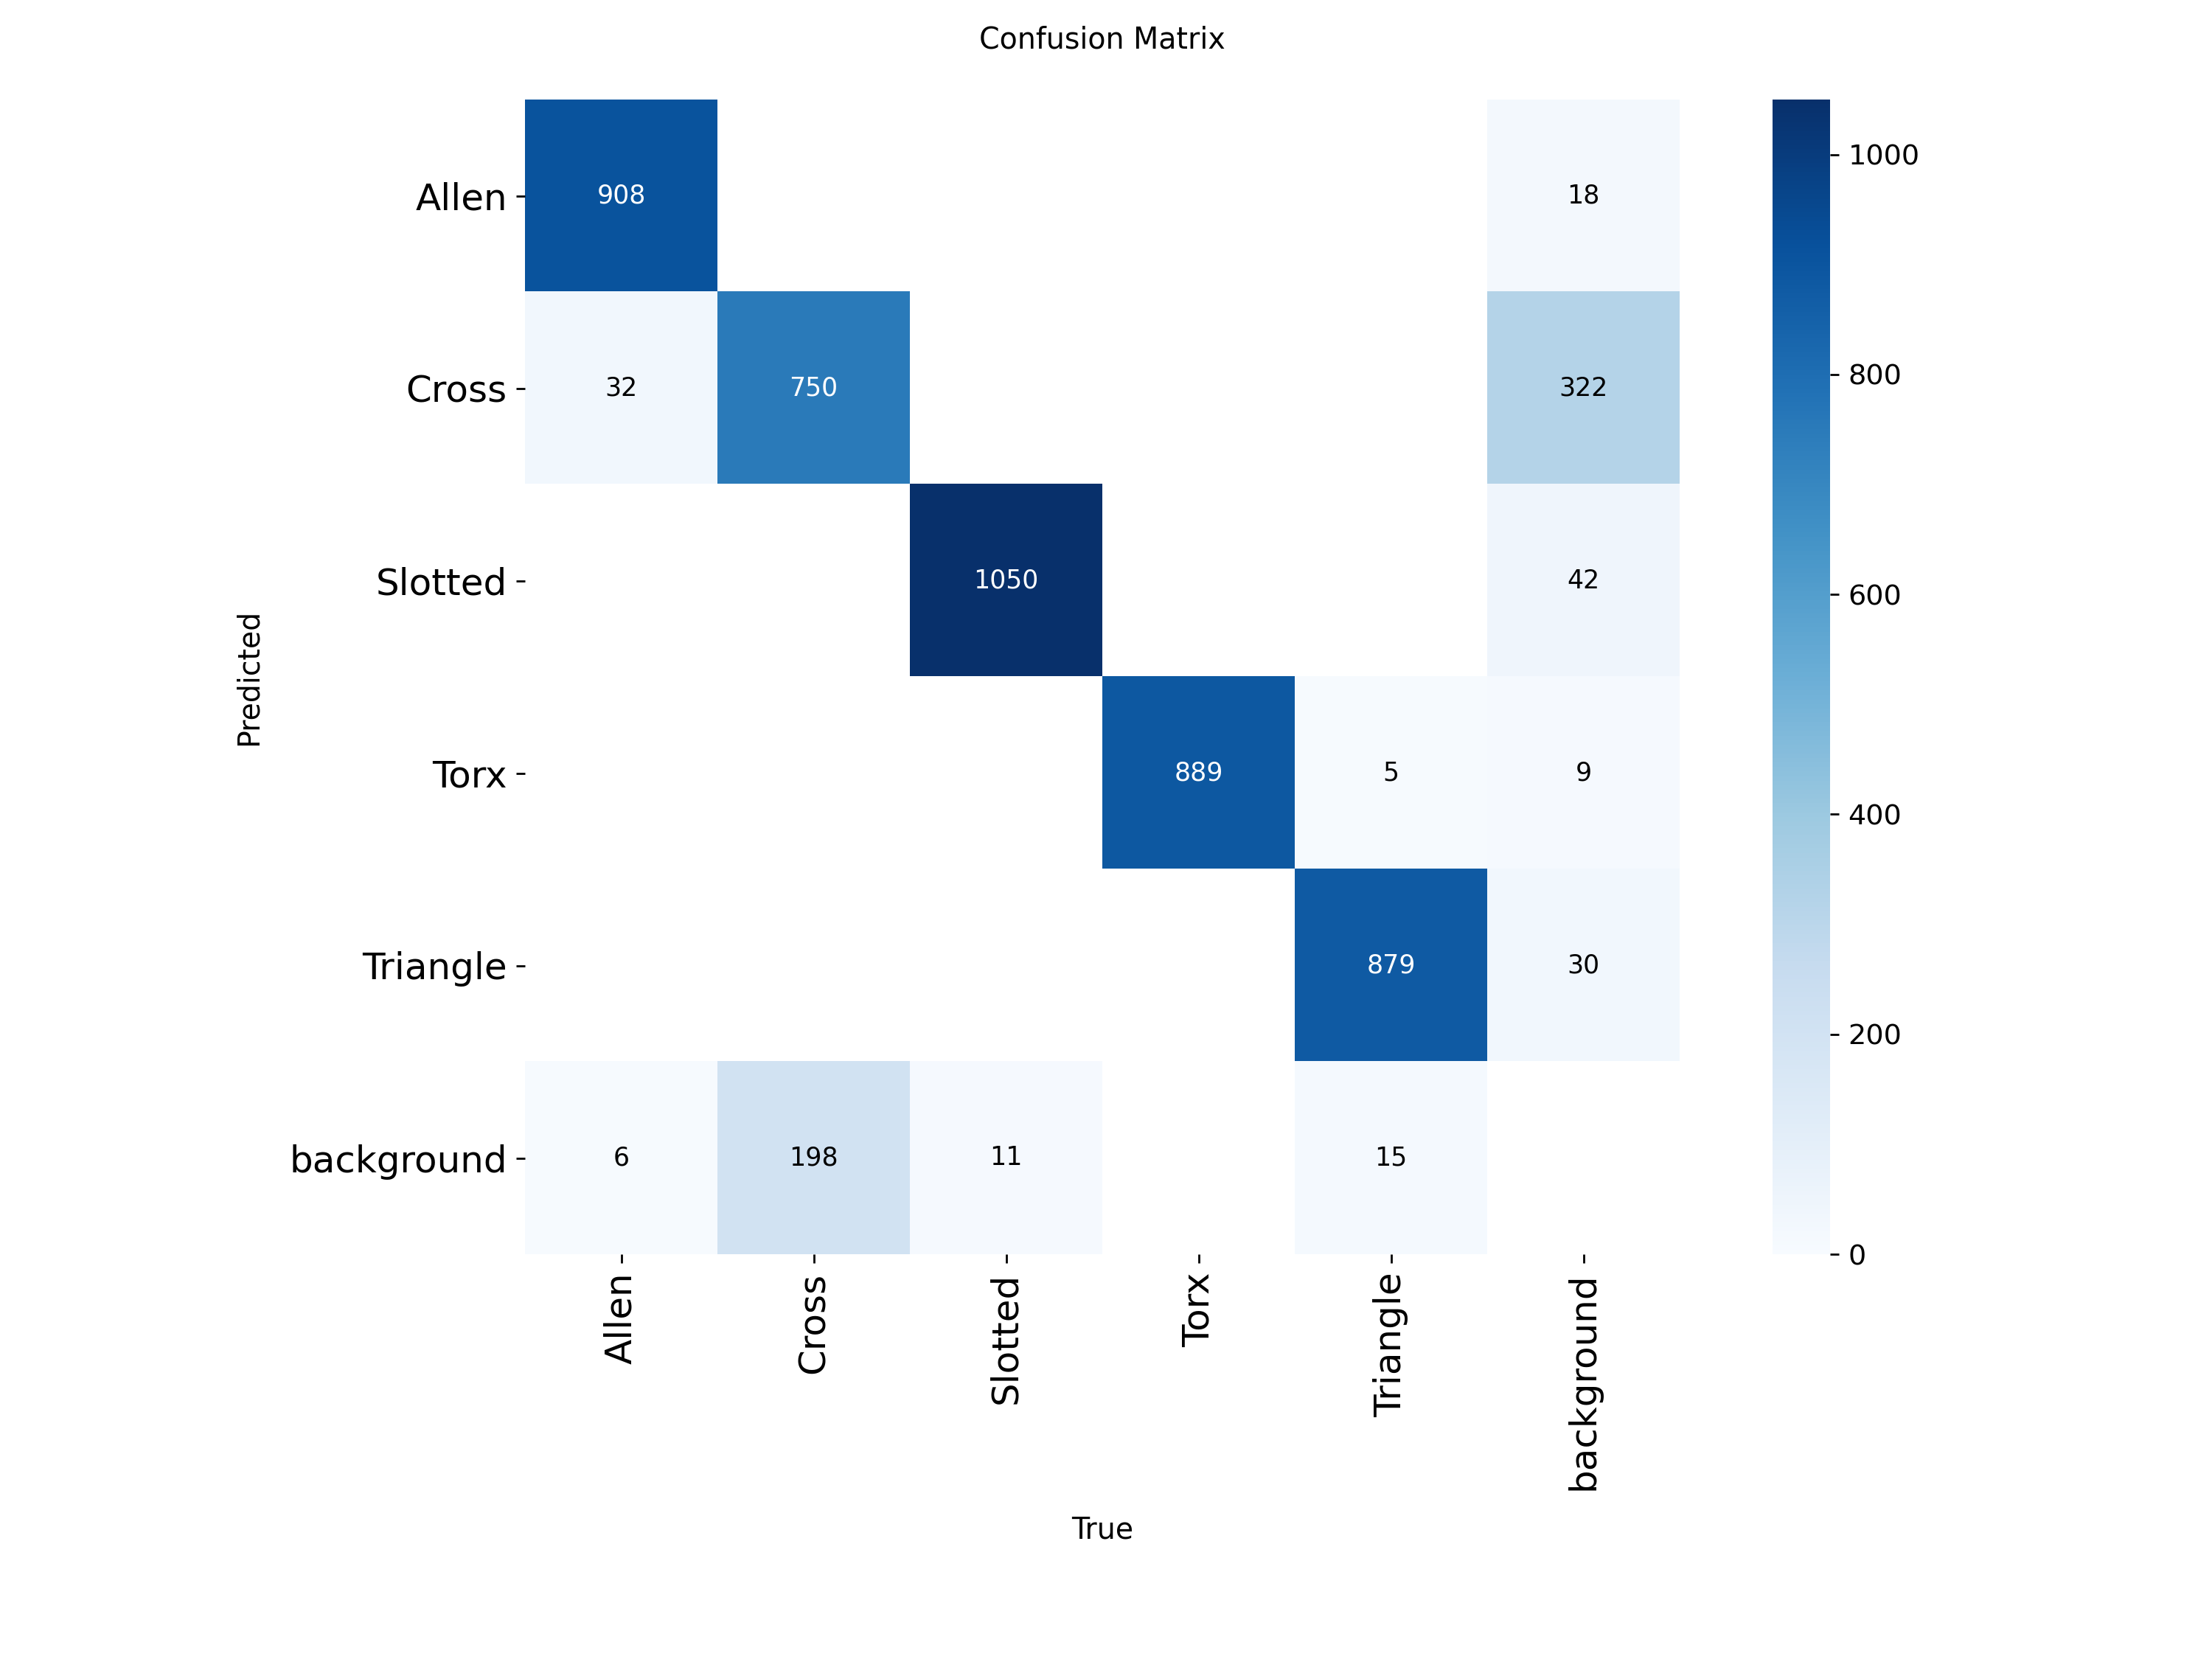

── results.png ──


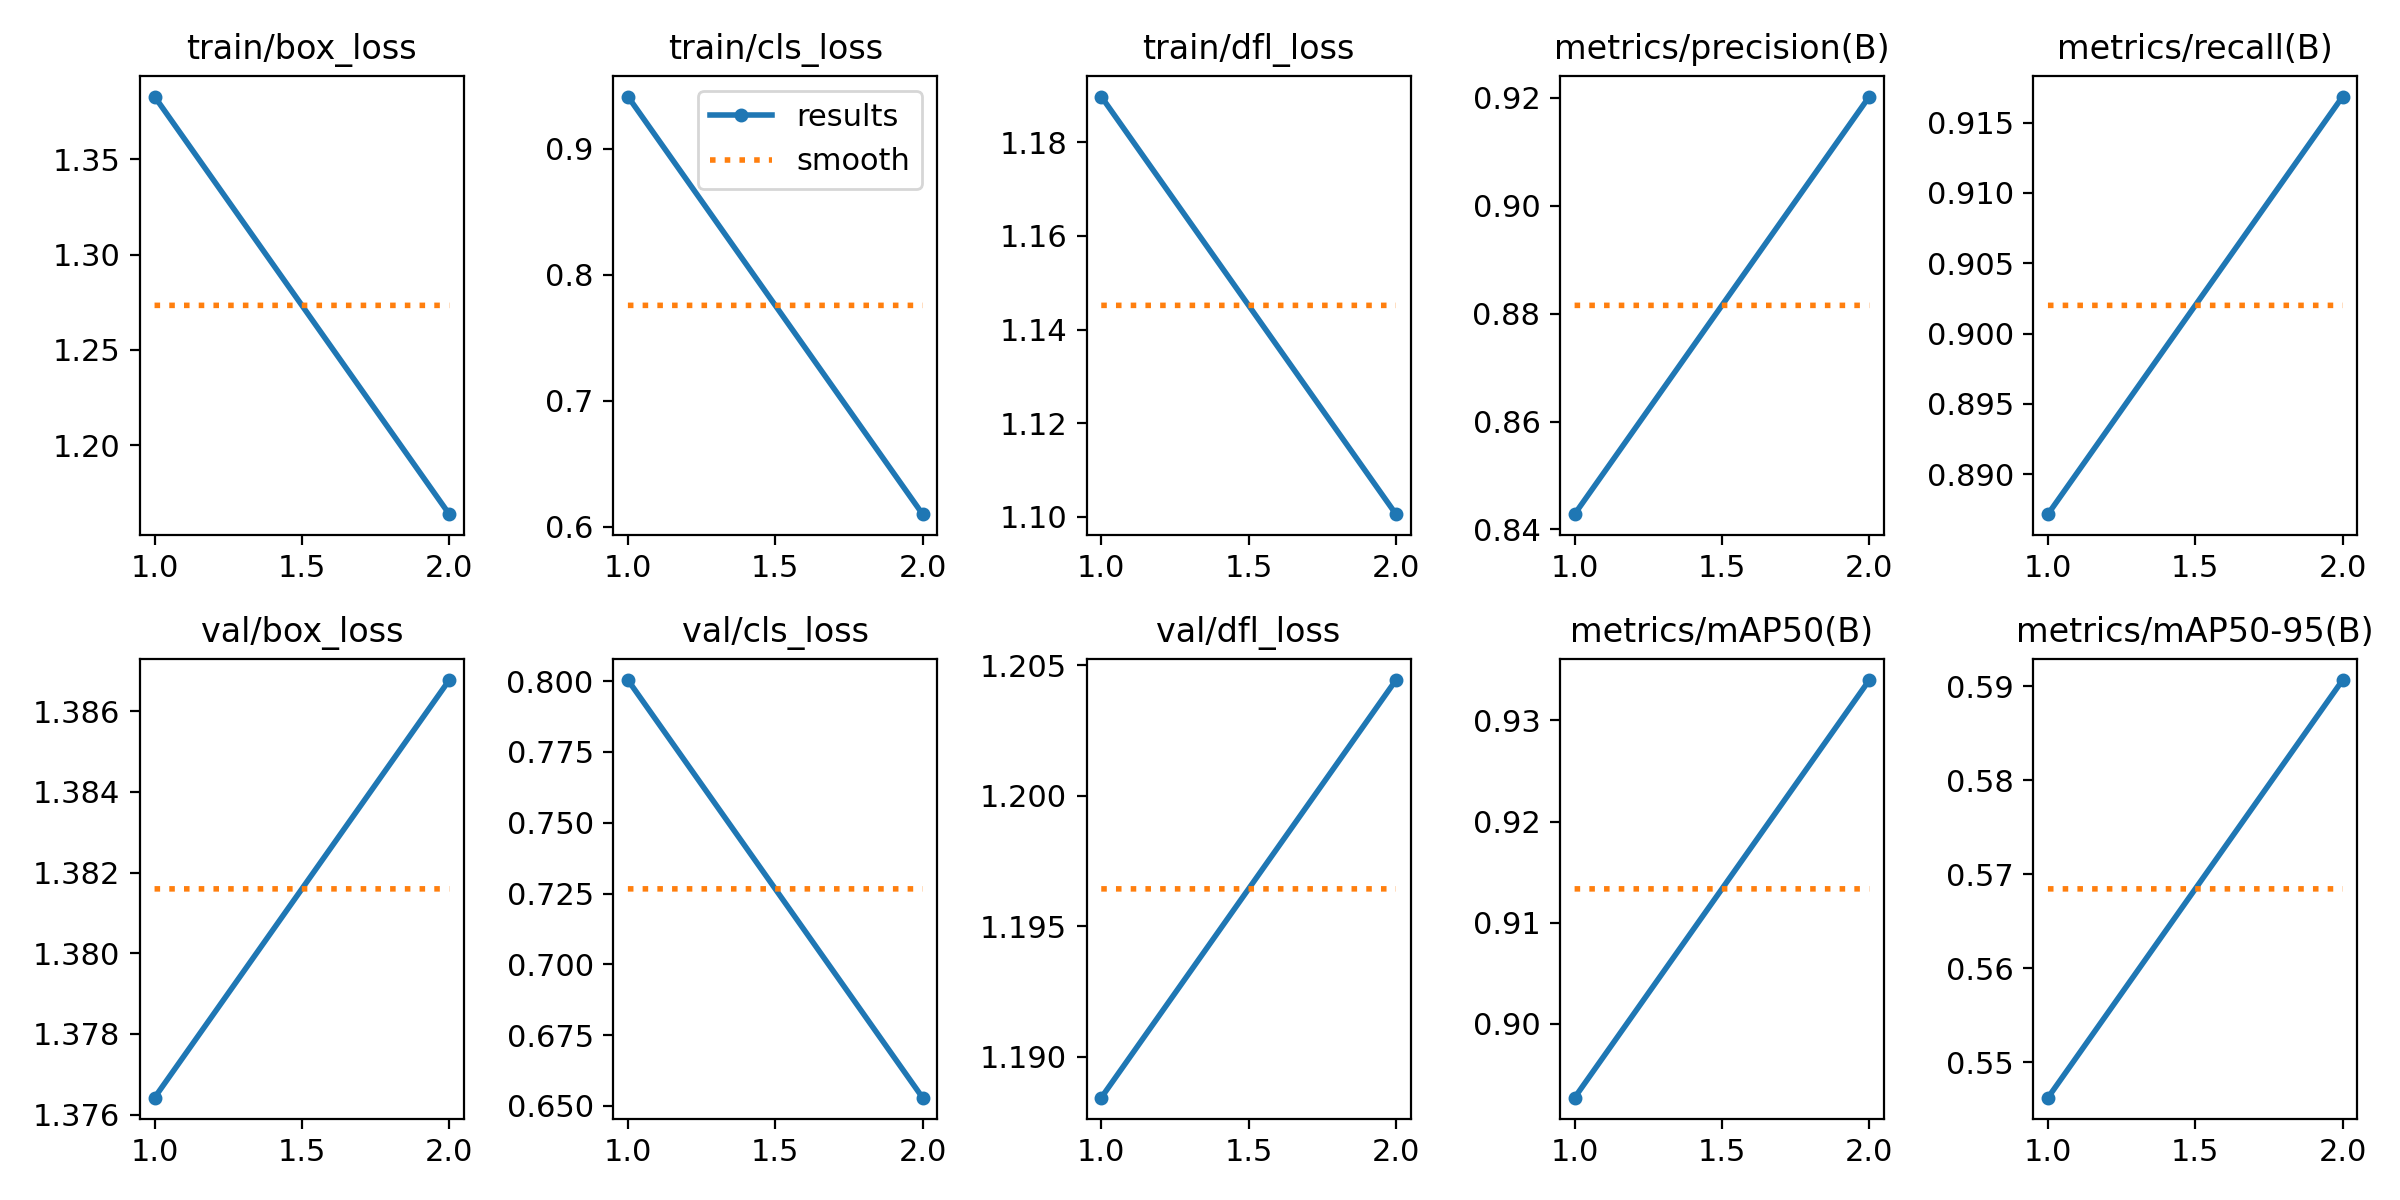

── labels.jpg ──


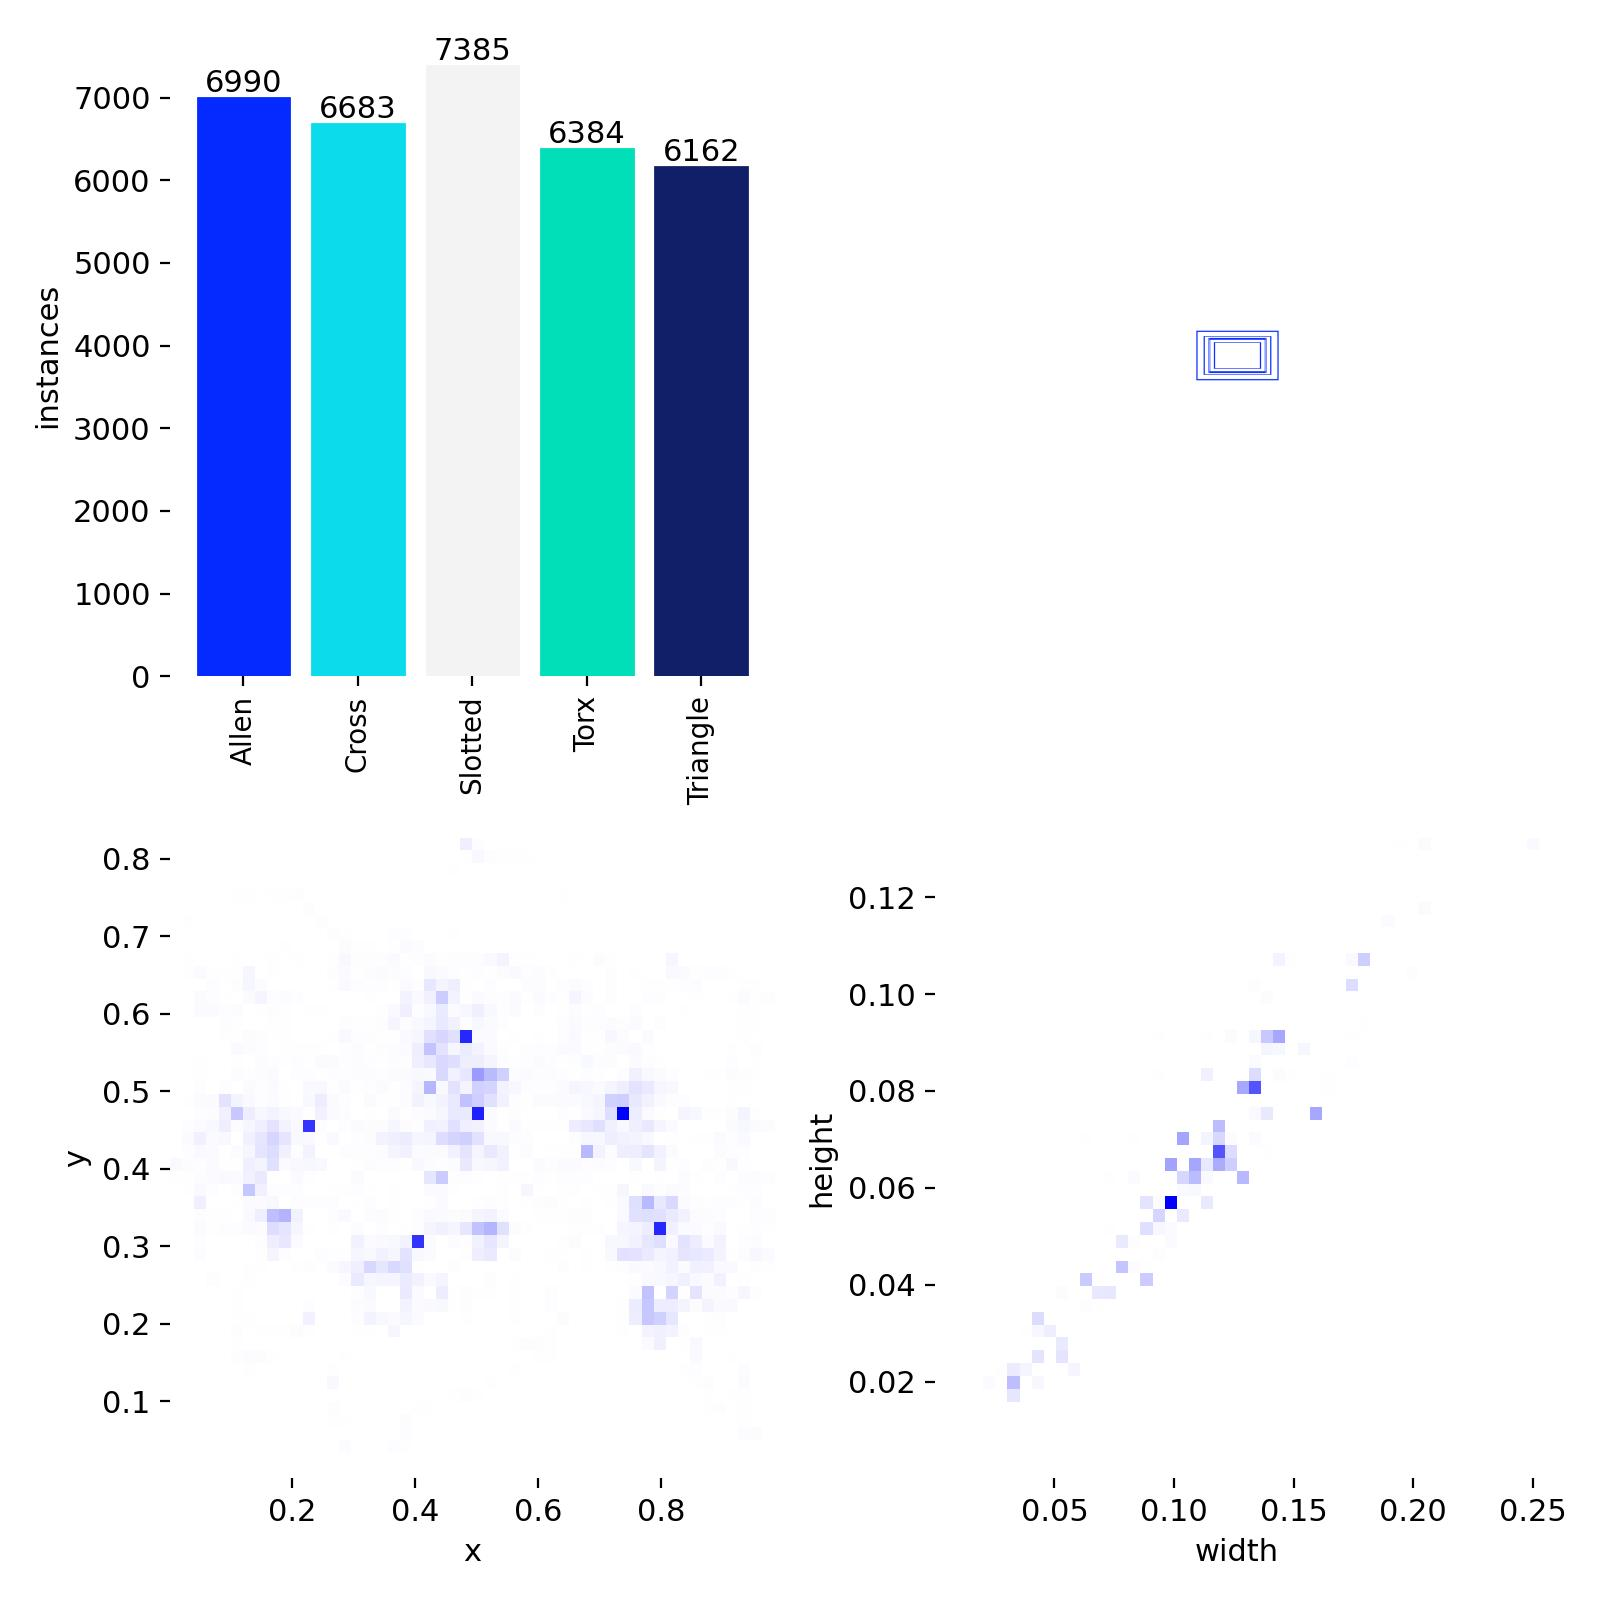

In [ ]:

# ── YOLO-generated plots (confusion matrix, PR curve, F1 curve, labels) ──────
from IPython.display import display, Image as IPImage
from pathlib import Path

run_dir = Path(results.save_dir)
plot_files = [
    "confusion_matrix_normalized.png",
    "confusion_matrix.png",
    "PR_curve.png",
    "F1_curve.png",
    "results.png",
    "labels.jpg",
]

for fname in plot_files:
    p = run_dir / fname
    if p.exists():
        print(f"── {fname} ──")
        display(IPImage(filename=str(p), width=800))


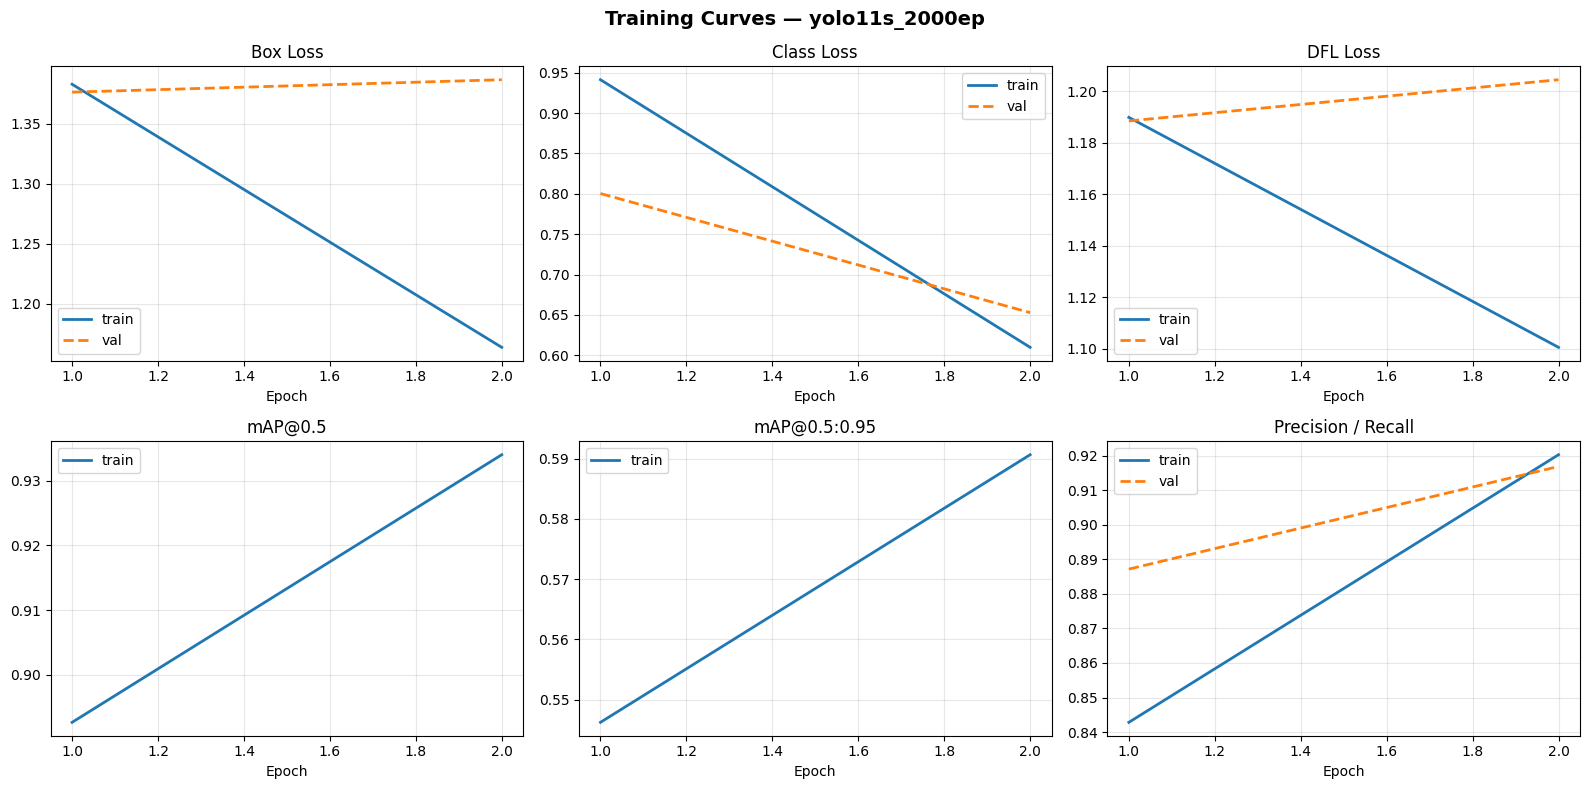

Saved → /content/training_curves.png


In [ ]:

# ── Training curves: loss & mAP over epochs ──────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path(results.save_dir) / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle(f"Training Curves — {RUN_NAME}", fontsize=14, fontweight='bold')

pairs = [
    ("train/box_loss",  "val/box_loss",  "Box Loss",       axes[0, 0]),
    ("train/cls_loss",  "val/cls_loss",  "Class Loss",     axes[0, 1]),
    ("train/dfl_loss",  "val/dfl_loss",  "DFL Loss",       axes[0, 2]),
    ("metrics/mAP50(B)",      None,      "mAP@0.5",        axes[1, 0]),
    ("metrics/mAP50-95(B)",   None,      "mAP@0.5:0.95",   axes[1, 1]),
    ("metrics/precision(B)",  "metrics/recall(B)", "Precision / Recall", axes[1, 2]),
]

for train_col, val_col, title, ax in pairs:
    if train_col in df.columns:
        ax.plot(df["epoch"], df[train_col], label="train", linewidth=2)
    if val_col and val_col in df.columns:
        ax.plot(df["epoch"], df[val_col], label="val", linewidth=2, linestyle='--')
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved → /content/training_curves.png")


## 5. Export

In [ ]:
# Export to ONNX (cross-platform, used by host PC inference)
model_best.export(
    format   = 'onnx',
    imgsz    = IMGSZ,
    opset    = 17,
    simplify = True,
    dynamic  = False,   # fixed batch=1 for real-time inference
)
print("ONNX export complete")

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/content/runs/detect/IRIS_screw_detection/yolo11s_2000ep6/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 9, 8400) (18.3 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 422ms
Prepared 4 packages in 14.64s
Installed 4 packages in 1.01s
 + colorama==0.4.6
 + onnx==1.20.1
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.88

requirements: AutoUpdate success ✅ 18.1s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.20.1 opset 17...
ONNX: slimming with onnxslim 0.1.88...
ONNX: export succes


image 1/1 /content/dataset/valid/images/Slotted-00437_jpg.rf.c0d74eb1f4243c3761f84b5cf1858c00.jpg: 640x384 6 Slotteds, 357.3ms
Speed: 16.0ms preprocess, 357.3ms inference, 6.2ms postprocess per image at shape (1, 3, 640, 384)


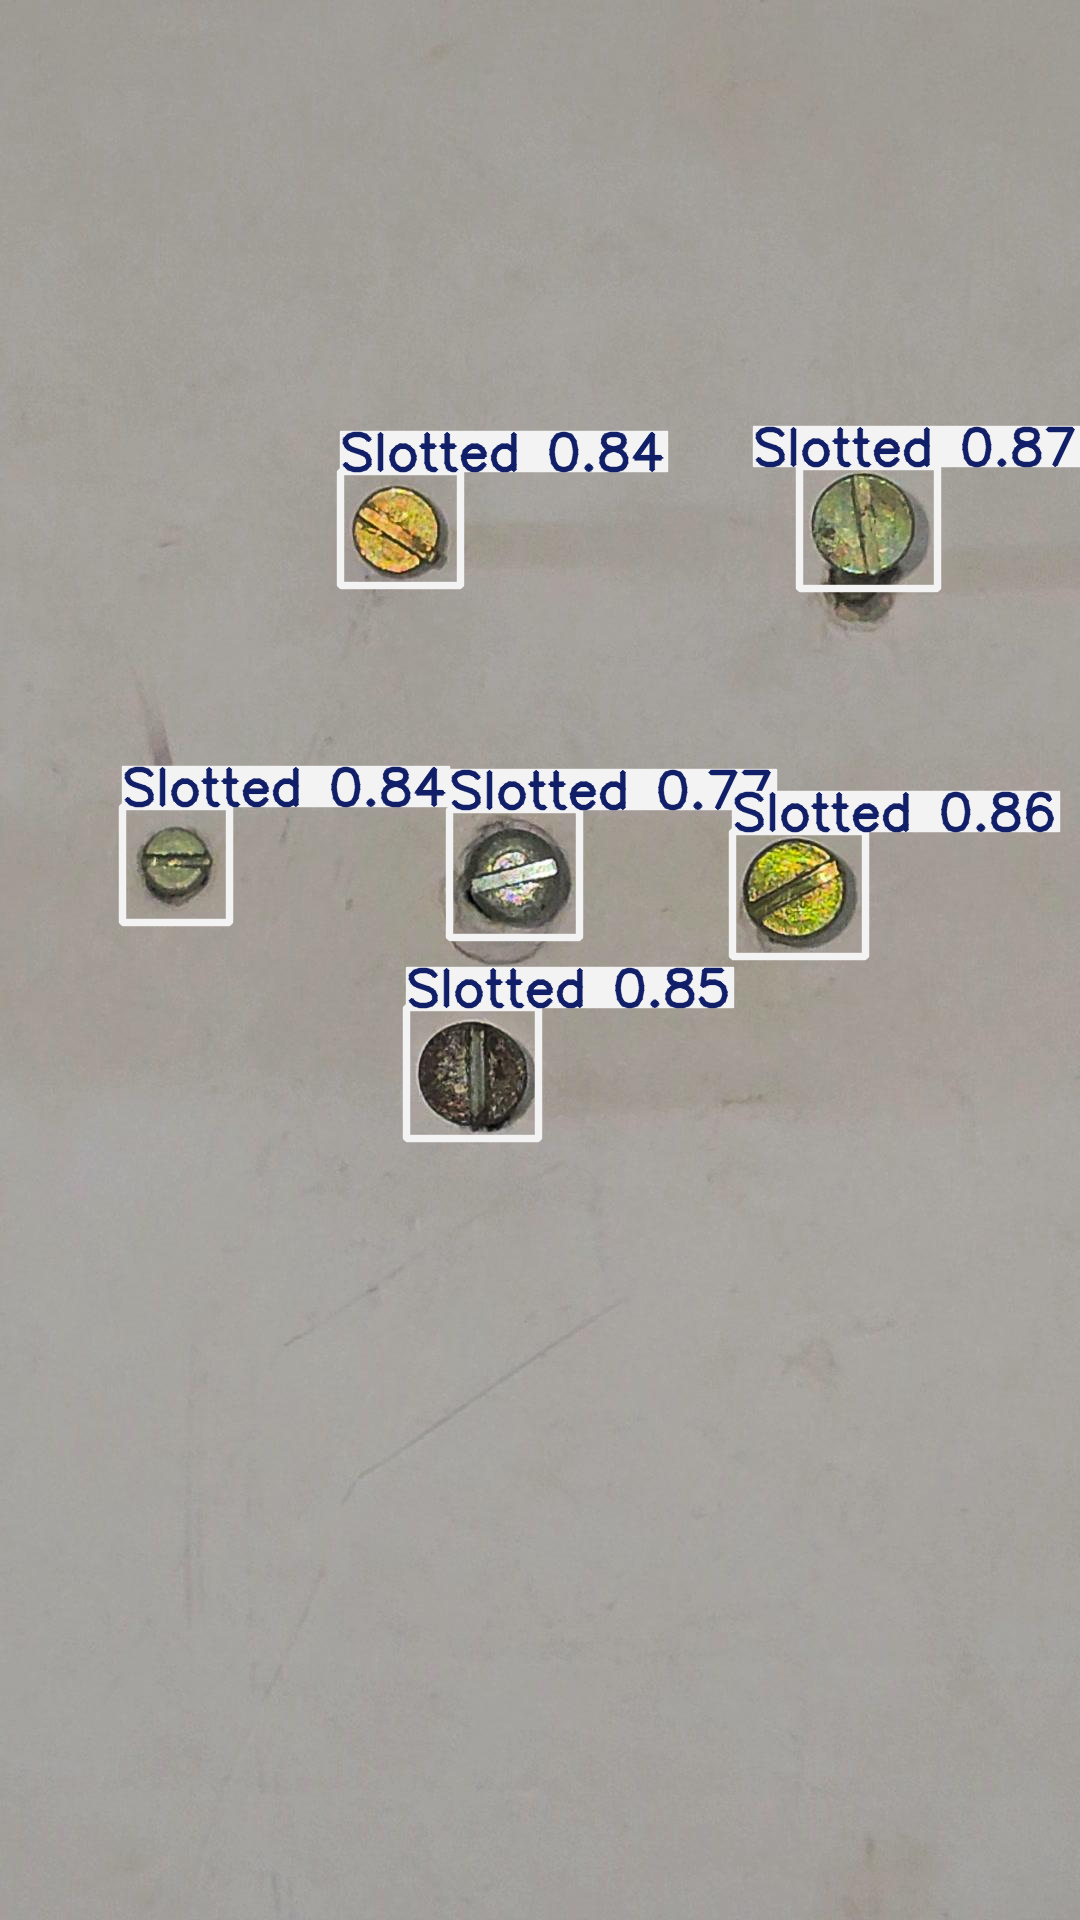

Detections on Slotted-00437_jpg.rf.c0d74eb1f4243c3761f84b5cf1858c00.jpg: 6 screws


In [ ]:
# Quick inference smoke-test on one val image
from pathlib import Path
import random

val_images = list((Path(dataset.location) / 'valid' / 'images').glob('*'))
if val_images:
    sample = random.choice(val_images)
    preds = model_best(str(sample), conf=0.25, iou=0.45)
    preds[0].show()   # inline display in Colab
    print(f"Detections on {sample.name}: {len(preds[0].boxes)} screws")

## 6. Download Weights

In [ ]:
import shutil
from google.colab import files
from pathlib import Path

run_dir   = Path(results.save_dir)
best_pt   = run_dir / 'weights' / 'best.pt'
best_onnx = best_pt.with_suffix('.onnx')

shutil.copy(best_pt, '/content/IRIS_best.pt')
if best_onnx.exists():
    shutil.copy(best_onnx, '/content/IRIS_best.onnx')

shutil.make_archive('/content/IRIS_run', 'zip', str(run_dir))

print("Downloading weights...")
files.download('/content/IRIS_best.pt')
if Path('/content/IRIS_best.onnx').exists():
    files.download('/content/IRIS_best.onnx')
files.download('/content/IRIS_run.zip')
print("Done — place best.pt and best.onnx in IRIS Progect/models/")

---
## Appendix — Augmented Dataset Builder (Optional)
> Run this section **only** if your downloaded dataset has fewer than 1000 images.  
> It uses Albumentations to synthetically expand the dataset 3x via heavy augmentation.

In [ ]:
# OPTIONAL: run only if dataset < 1000 images
!pip install -q albumentations

import albumentations as A
import cv2
import numpy as np
from pathlib import Path

aug_pipeline = A.Compose([
    A.RandomBrightnessContrast(p=0.6),
    A.GaussNoise(var_limit=(10, 50), p=0.4),
    A.MotionBlur(blur_limit=5, p=0.3),
    A.HueSaturationValue(p=0.4),
    A.RandomGamma(p=0.3),
    A.CLAHE(p=0.3),
    A.Perspective(scale=(0.02, 0.05), p=0.3),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

def augment_split(split='train', multiplier=3):
    img_dir  = Path(dataset.location) / split / 'images'
    lbl_dir  = Path(dataset.location) / split / 'labels'
    added = 0
    for img_path in list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png')):
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if not lbl_path.exists():
            continue
        img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
        bboxes, classes = [], []
        for line in lbl_path.read_text().strip().splitlines():
            parts = line.split()
            classes.append(int(parts[0]))
            bboxes.append([float(x) for x in parts[1:5]])
        for i in range(multiplier - 1):
            try:
                out = aug_pipeline(image=img, bboxes=bboxes, class_labels=classes)
            except Exception:
                continue
            stem = f"{img_path.stem}_aug{i}"
            cv2.imwrite(str(img_dir / f"{stem}.jpg"),
                        cv2.cvtColor(out['image'], cv2.COLOR_RGB2BGR))
            lines = [f"{c} {' '.join(f'{v:.6f}' for v in b)}"
                     for c, b in zip(out['class_labels'], out['bboxes'])]
            (lbl_dir / f"{stem}.txt").write_text('\n'.join(lines))
            added += 1
    print(f"{split}: added {added} augmented images")

augment_split('train', multiplier=3)
augment_split('valid', multiplier=2)

# Re-count
new_total = sum(count(Path(dataset.location) / s / 'images') for s in ['train','valid','test'])
print(f"Total after augmentation: {new_total} images")

Argument(s) 'var_limit' are not valid for transform GaussNoise


KeyboardInterrupt: 